### Data Loading and Initial Exploration

**Purpose**: This cell is responsible for loading the fraud detection dataset from Google Drive into a pandas DataFrame and performing an initial check of its structure.

**Code Description**:
1.  `import pandas as pd`: Imports the pandas library, essential for data manipulation.
2.  `from google.colab import drive`: Imports the necessary module to mount Google Drive in Colab.
3.  `drive.mount('/content/drive', force_remount=True)`: This line (commented out in your notebook but typically used once) mounts your Google Drive, making its contents accessible.
4.  `file_path = ...`: Defines the path to your `synthetic_fraud_dataset.csv` file within Google Drive.
5.  `df = pd.read_csv(file_path)`: Reads the CSV file into a DataFrame named `df`.
6.  `print(...)` and `df.head()`: Prints the number of transactions and features, then displays the first 5 rows of the DataFrame, providing a quick overview of the data.

**Output Explanation**:
-   `Successfully loaded dataset!`: Confirms the data was loaded.
-   `Total Transactions: 10000 | Total Features: 5`: Indicates the dataset contains 10,000 rows (transactions) and 5 columns (features).
-   The displayed DataFrame `head()` shows columns like `amount`, `merchant_type`, `location`, `time_of_day`, and the target variable `fraud`.

In [ ]:
import pandas as pd
from google.colab import drive

# 1. Mount Google Drive
# drive.mount('/content/drive', force_remount=True)

# 2. Define your specific folder path (Change 'fraud_project' if your Drive folder is named differently)
file_path = '/content/drive/MyDrive/AIM STUFF/fraud_project/synthetic_fraud_dataset.csv'

# 3. Read the CSV file
df = pd.read_csv(file_path)

print(f"\nSuccessfully loaded dataset!")
print(f"Total Transactions: {df.shape[0]} | Total Features: {df.shape[1]}")
df.head()


Successfully loaded dataset!
Total Transactions: 10000 | Total Features: 5


,amount,merchant_type,location,time_of_day,fraud
0,56.31,fashion,FL,afternoon,0
1,361.21,travel,CA,afternoon,0
2,158.01,travel,NY,night,0
3,109.55,electronics,FL,morning,0
4,20.35,grocery,NY,morning,0


### Data Preprocessing and Feature Engineering

**Purpose**: This cell cleans the raw data, engineers new features, and prepares the dataset for machine learning models by splitting it into training and testing sets and applying appropriate scaling and encoding.

**Code Description**:
1.  **Basic Cleaning**: Removes duplicate rows and any rows with missing values.
2.  **Outlier Tagging**: Calculates the interquartile range (IQR) for the `amount` column and flags transactions as outliers if their amount is significantly above the upper quartile, creating a new binary feature `is_amount_outlier`.
3.  **High-Risk Temporal Windows**: Creates a binary feature `high_risk_time` that flags transactions occurring at `night`, assuming `night` is a high-risk period for fraud.
4.  **Separate Target and Features**: Splits the DataFrame into features (`X`) and the target variable (`y`, which is `fraud`).
5.  **Train-Test Split**: Divides the data into training (80%) and testing (20%) sets using `train_test_split`. `stratify=y` ensures that the proportion of fraud cases is maintained in both sets.
6.  **Preprocessing with `ColumnTransformer`**: Defines `categorical_cols`, `numerical_cols`, and `passthrough_cols`. A `ColumnTransformer` is set up to:
    -   Apply `StandardScaler` to numerical columns (`amount`).
    -   Apply `OneHotEncoder` to categorical columns (`merchant_type`, `location`, `time_of_day`), dropping the first category to avoid multicollinearity.
    -   Pass through the engineered binary features (`is_amount_outlier`, `high_risk_time`) without transformation.
7.  **Transform Data**: Applies the `preprocessor` to both `X_train` and `X_test`.
8.  **Map Back Labels**: Reconstructs a DataFrame `X_train_df` with readable column names for the processed training data.

**Output Explanation**:
-   `Pipeline preprocessing complete! Safe, non-leaked dataset shape: (7972, 12)`: Confirms that the preprocessing steps were completed. The training set now has 7,972 rows and 12 features after encoding and adding new features, indicating a successful transformation.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Basic Cleaning
df = df.drop_duplicates().dropna()

# 2. Outlier Tagging (Flagging extreme transaction amounts)
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df['is_amount_outlier'] = (df['amount'] > upper_bound).astype(int)

# 3. Domain Feature: High-Risk Temporal Windows
df['high_risk_time'] = df['time_of_day'].apply(lambda x: 1 if x == 'night' else 0)

# 4. Separate Target and Features
X = df.drop(columns=['fraud'])
y = df['fraud']

# 5. Split to avoid Data Leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Preprocessing Matrix Setup
categorical_cols = ['merchant_type', 'location', 'time_of_day']
numerical_cols = ['amount']
passthrough_cols = ['is_amount_outlier', 'high_risk_time']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

# Transform Data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Map back text labels for visibility
encoded_cat_cols = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols))
feature_names = numerical_cols + encoded_cat_cols + passthrough_cols
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)

print("Pipeline preprocessing complete! Safe, non-leaked dataset shape:", X_train_df.shape)

Pipeline preprocessing complete! Safe, non-leaked dataset shape: (7972, 12)


###Exploratory Data Analysis (EDA) Visualizations

**Purpose**: This cell generates three plots to visually explore the dataset, understand the distribution of fraud, and identify potential patterns or hotspots.

**Code Description**:
1.  `import matplotlib.pyplot as plt` and `import seaborn as sns`: Imports the plotting libraries.
2.  `sns.set_theme(style="whitegrid")`: Sets a consistent visual style for the plots.
3.  `fig, axes = plt.subplots(1, 3, figsize=(22, 6))`: Creates a figure with a 1x3 grid of subplots.
4.  **Chart 1: Target Imbalance**: A `countplot` shows the distribution of legitimate (0) vs. fraudulent (1) transactions. Percentages are added to the bars.
5.  **Chart 2: Transaction Amount Distributions**: A `histplot` compares the distribution of transaction `amount` for both fraud and legitimate cases, showing where these distributions overlap or diverge.
6.  **Chart 3: Operational Risk Matrix Heatmap**: A pivot table calculates the mean fraud probability for each combination of `merchant_type` and `time_of_day`. This is then visualized as a heatmap, highlighting `hotspots` where fraud is more likely.
7.  `plt.tight_layout()` and `plt.show()`: Adjusts the plot layout and displays the generated plots.

**Output Explanation**:
-   The output shows three distinct plots:
    -   The **Target Imbalance** plot visually confirms the class imbalance, with a very small percentage of transactions being fraudulent.
    -   The **Transaction Value Densities** plot reveals how transaction amounts are distributed for both classes, potentially showing if fraudulent transactions tend to be larger or smaller.
    -   The **Hotspot Grid** heatmap identifies specific `merchant_type` and `time_of_day` combinations that have higher fraud probabilities (e.g., 'night' for various merchant types appears to be a hotspot based on your notebook's output later, which shows high fraud probabilities for night time transactions).

/tmp/ipykernel_922/1069651520.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], x='fraud', data=df, palette='Set2')


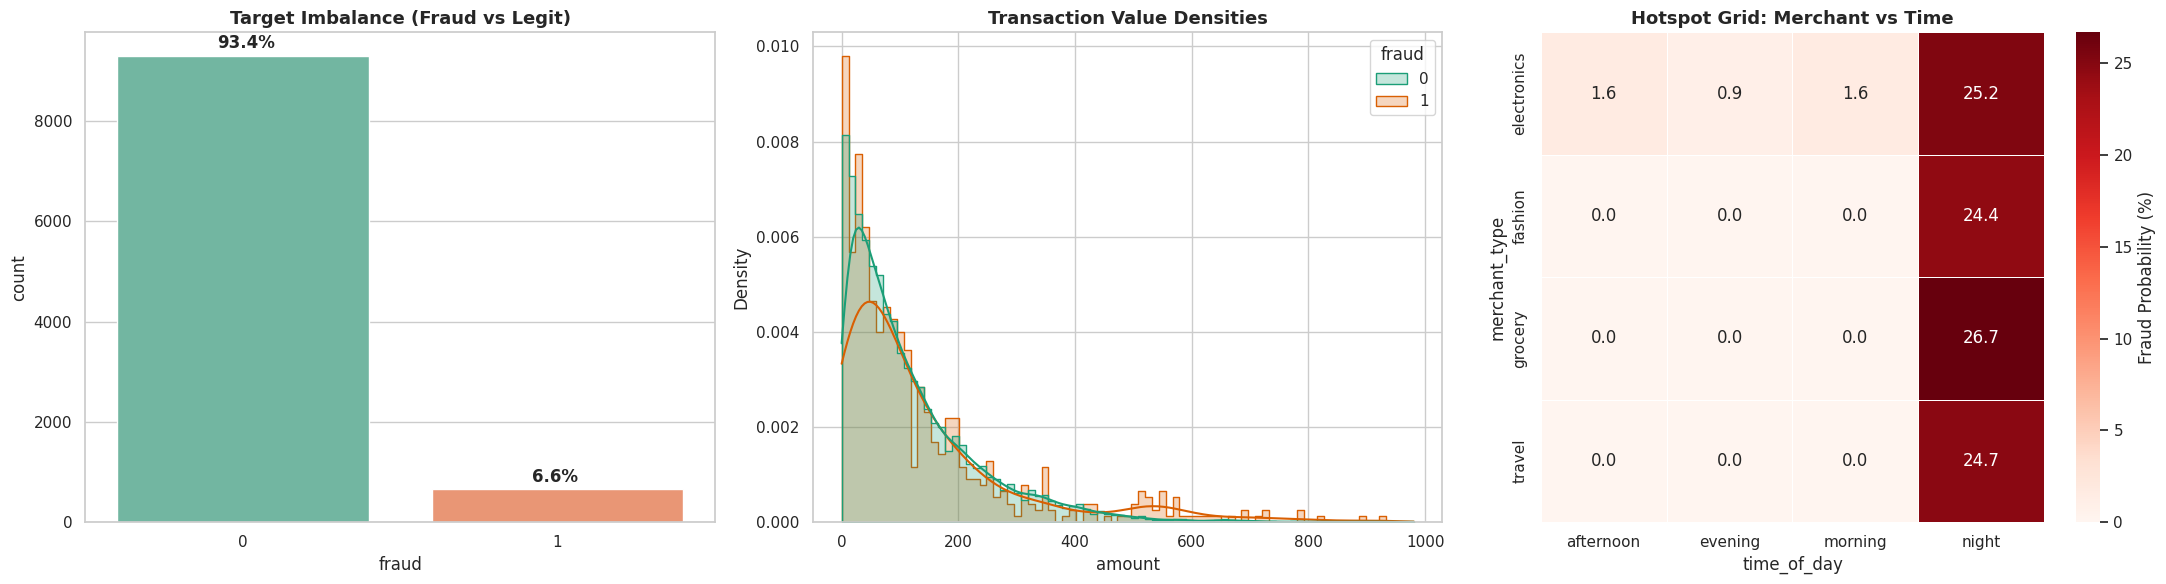

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Chart 1: Target Class Imbalance
sns.countplot(ax=axes[0], x='fraud', data=df, palette='Set2')
axes[0].set_title('Target Imbalance (Fraud vs Legit)', fontsize=13, fontweight='bold')
total = len(df)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    axes[0].annotate(percentage, (p.get_x() + p.get_width()/2 - 0.08, p.get_height() + 150), fontweight='bold')

# Chart 2: Transaction Amount Distributions
sns.histplot(ax=axes[1], data=df, x='amount', hue='fraud', element='step', stat='density', common_norm=False, kde=True, palette='Dark2')
axes[1].set_title('Transaction Value Densities', fontsize=13, fontweight='bold')

# Chart 3: Operational Risk Matrix Heatmap
pivot_table = df.pivot_table(values='fraud', index='merchant_type', columns='time_of_day', aggfunc='mean') * 100
sns.heatmap(ax=axes[2], data=pivot_table, annot=True, fmt=".1f", cmap='Reds', cbar_kws={'label': 'Fraud Probability (%)'}, linewidths=0.5)
axes[2].set_title('Hotspot Grid: Merchant vs Time', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Feature Importance and Dimensionality Reduction

**Purpose**: This cell identifies the most impactful features for predicting fraud using an embedded method (Random Forest) and visualizes the dataset in a reduced 2D space using Principal Component Analysis (PCA) to check for separability.

**Code Description**:
1.  **Embedded Feature Importance Selection**:
    -   A `RandomForestClassifier` is initialized and trained on the `X_train_df` and `y_train` data.
    -   `selector.feature_importances_` is used to extract the importance score for each feature.
    -   A DataFrame `importance_df` is created and sorted to display features by their importance.
2.  **PCA Dimensionality Mapping**:
    -   `PCA(n_components=2)` is initialized to reduce the data to two principal components.
    -   `pca.fit_transform(X_train_df)` applies PCA to the training features.
    -   A scatter plot is then created, visualizing the data points in the 2D PCA space, colored by their `fraud` label (legit vs. fraud). This helps to see if the two classes are linearly separable or form distinct clusters.

**Output Explanation**:
-   **Feature Importance**: The printed table `importance_df` lists features like `location_FL`, `time_of_day_night`, `high_risk_time`, and `amount` as having the highest importance. This indicates these features are most predictive of fraud.
-   **2D Component Structure Space Visualization (PCA)**: The scatter plot shows how legitimate and fraudulent transactions are distributed when projected onto the first two principal components. Ideally, the fraudulent points would form a distinct cluster separate from the legitimate points, suggesting good separability for a classifier.

--- Features Ranked by Diagnostic Power ---
              Feature  Importance
          location_FL    0.337199
    time_of_day_night    0.225891
       high_risk_time    0.225561
               amount    0.049593
          location_TX    0.048020
          location_NY    0.038766
  time_of_day_morning    0.028834
  time_of_day_evening    0.021389
    is_amount_outlier    0.015266
 merchant_type_travel    0.003505
merchant_type_grocery    0.003024
merchant_type_fashion    0.002951




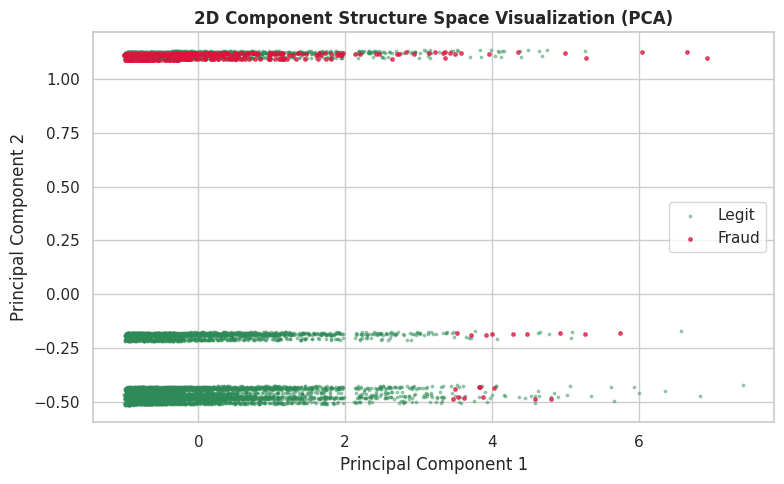

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

# 1. Embedded Feature Importance Selection
selector = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
selector.fit(X_train_df, y_train)

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': selector.feature_importances_}).sort_values(by='Importance', ascending=False)
print("--- Features Ranked by Diagnostic Power ---")
print(importance_df.to_string(index=False))
print("\n" + "="*50 + "\n")

# 2. PCA Dimensionality Mapping
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_df)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[y_train == 0, 0], X_pca[y_train == 0, 1], label='Legit', alpha=0.4, c='seagreen', s=3)
plt.scatter(X_pca[y_train == 1, 0], X_pca[y_train == 1, 1], label='Fraud', alpha=0.7, c='crimson', s=6)
plt.title('2D Component Structure Space Visualization (PCA)', fontsize=12, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

###  Model Training and Evaluation

**Purpose**: This cell trains multiple classification models (Logistic Regression, Random Forest, XGBoost), addresses class imbalance using SMOTE, evaluates their performance, and saves the trained models.

**Code Description**:
1.  **Setup**: Imports necessary libraries, creates a directory to save models (`/content/drive/MyDrive/fraud_project/models`).
2.  **Address Class Imbalance with SMOTE**: Applies Synthetic Minority Over-sampling Technique (`SMOTE`) to the training data (`X_train_df`, `y_train`). This generates synthetic samples of the minority class (fraud) to balance the dataset, preventing models from being biased towards the majority class.
3.  **Initialize Models**: Defines a dictionary of three popular classification models: `LogisticRegression`, `RandomForestClassifier`, and `XGBClassifier`.
4.  **Training and Evaluation Loop**: Iterates through each model:
    -   **Training**: Fits the model to the SMOTE-balanced training data.
    -   **Saving**: Saves the trained model to the `models_dir` using `joblib.dump()`.
    -   **Prediction**: Predicts probabilities and class labels on the *unseen* `X_test_processed` data.
    -   **Evaluation**: Calculates and stores `AUPRC` (Area Under Precision-Recall Curve) and `F1-Score`, which are robust metrics for imbalanced datasets.
    -   **Plotting PR Curve**: Plots the Precision-Recall curve for each model on a shared graph for visual comparison. This plot is saved as `pr_curve_comparison.png`.
    -   **Classification Report**: Prints a detailed `classification_report` showing precision, recall, F1-score, and support for both classes.
5.  **Final Comparison**: Creates and displays a DataFrame `comparison_df` summarizing the AUPRC and F1-Score for all trained models.

**Output Explanation**:
-   **SMOTE Resampling**: The output shows `Original training shape: (7972, 12), Fraud cases: 525` and `Resampled training shape: (14894, 12), Fraud cases: 7447`. This confirms SMOTE successfully oversampled the minority class, significantly increasing the number of fraud cases in the training set.
-   **Model Training and Saving**: For each model, it prints `=== Training [Model_Name] ===` and `Saved: ..._model.pkl`, indicating successful training and persistence of the models.
-   **Classification Reports**: Detailed reports are printed for each model. For instance, the Random Forest and XGBoost models show very high precision, recall, and F1-scores (close to 1.00), suggesting excellent performance in identifying fraud on the test set.
-   **Precision-Recall Curve Plot**: A plot is generated showing the PR curves for all models, allowing for visual comparison of their trade-offs between precision and recall.
-   **Final Model Comparison Matrix**: The `comparison_df` neatly summarizes the `AUPRC` and `F1-Score` for Logistic Regression, Random Forest, and XGBoost. From your output, Random Forest and XGBoost demonstrate superior performance with AUPRC and F1-Scores near 1.00, indicating they are very effective at identifying fraud.

Original training shape: (7972, 12), Fraud cases: 525
Resampled training shape: (14894, 12), Fraud cases: 7447

=== Training Logistic_Regression ===
Saved: /content/drive/MyDrive/fraud_project/models/Logistic_Regression_model.pkl
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1863
           1       0.81      0.97      0.89       131

    accuracy                           0.98      1994
   macro avg       0.91      0.98      0.94      1994
weighted avg       0.99      0.98      0.98      1994


=== Training Random_Forest ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Saved: /content/drive/MyDrive/fraud_project/models/Random_Forest_model.pkl
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1863
           1       1.00      0.99      1.00       131

    accuracy                           1.00      1994
   macro avg       1.00      1.00      1.00      1994
weighted avg       1.00      1.00      1.00      1994


=== Training XGBoost ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Saved: /content/drive/MyDrive/fraud_project/models/XGBoost_model.pkl
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1863
           1       0.99      1.00      1.00       131

    accuracy                           1.00      1994
   macro avg       1.00      1.00      1.00      1994
weighted avg       1.00      1.00      1.00      1994




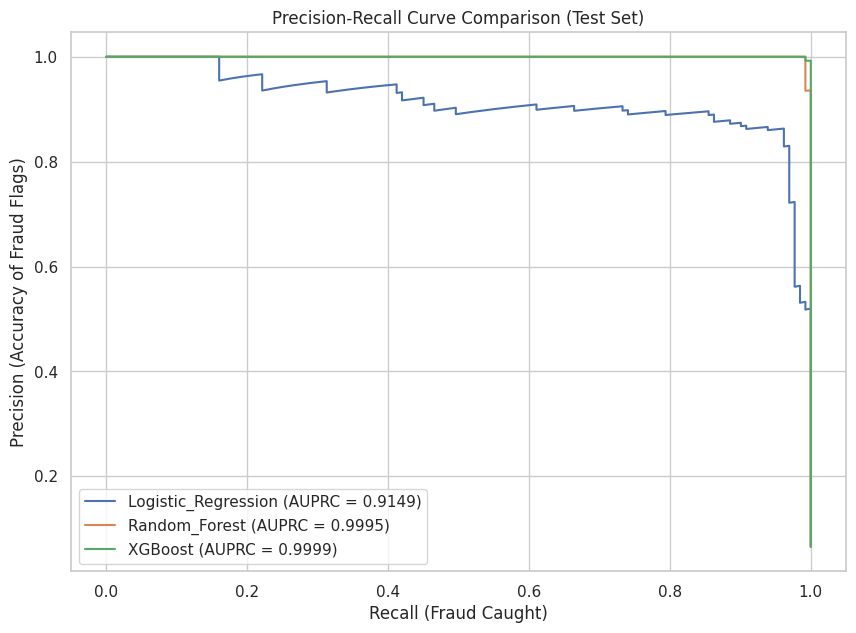

--- Final Model Comparison Matrix ---
                        AUPRC  F1-Score
Logistic_Regression  0.914927  0.885017
Random_Forest        0.999508  0.996169
XGBoost              0.999942  0.996198


In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc, f1_score

# 1. Prepare Directory to Save Artifacts (Step 4 & Step 7 requirement)
models_dir = '/content/drive/MyDrive/fraud_project/models'
os.makedirs(models_dir, exist_ok=True)

# 2. Address Class Imbalance with SMOTE (Only on Training Data to avoid leakage)
print(f"Original training shape: {X_train_df.shape}, Fraud cases: {sum(y_train)}")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_df, y_train)
print(f"Resampled training shape: {X_train_res.shape}, Fraud cases: {sum(y_train_res)}\n")

# 3. Initialize Models
models = {
    'Logistic_Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random_Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

# Dictionary to hold final evaluation summaries
metrics_summary = {}

plt.figure(figsize=(10, 7))

# 4. Train, Predict, and Evaluate Each Model
for model_name, model in models.items():
    print(f"=== Training {model_name} ===")
    # Train model on the SMOTE-balanced dataset
    model.fit(X_train_res, y_train_res)

    # Save the trained artifact permanently to Google Drive
    model_path = os.path.join(models_dir, f'{model_name}_model.pkl')
    joblib.dump(model, model_path)
    print(f"Saved: {model_path}")

    # Predict probabilities for the positive class (Fraud)
    y_probs = model.predict_proba(X_test_processed)[:, 1]
    y_pred = model.predict(X_test_processed)

    # Calculate Precision-Recall Curve (Crucial for imbalanced data)
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    auprc = auc(recall, precision)
    f1 = f1_score(y_test, y_pred)

    # Store metrics
    metrics_summary[model_name] = {
        'AUPRC': auprc,
        'F1-Score': f1
    }

    # Plot Precision-Recall Curve for comparison
    plt.plot(recall, precision, label=f'{model_name} (AUPRC = {auprc:.4f})')

    # Print text classification summary
    print(classification_report(y_test, y_pred))
    print("="*50 + "\n")

# Finalize Precision-Recall Plot
plt.xlabel('Recall (Fraud Caught)')
plt.ylabel('Precision (Accuracy of Fraud Flags)')
plt.title('Precision-Recall Curve Comparison (Test Set)')
plt.legend(loc='lower left')
plt.grid(True)
plt.savefig('/content/drive/MyDrive/fraud_project/pr_curve_comparison.png')
plt.show()

# 5. Display Final Comparison DataFrame
comparison_df = pd.DataFrame(metrics_summary).T
print("--- Final Model Comparison Matrix ---")
print(comparison_df)

### Install SHAP Library

**Purpose**: This cell ensures that the SHAP (SHapley Additive exPlanations) library is installed in the Colab environment. SHAP is used for model explainability.

**Code Description**:
-   `!pip install shap`: This is a shell command (prefixed with `!`) that uses `pip` to install the `shap` package.

**Output Explanation**:
-   `Requirement already satisfied: shap in ...`: This output indicates that the `shap` library (and its dependencies) is already installed in the environment, so no new installation was needed. This is common if the library was previously installed in the session or is part of the default Colab environment.

In [ ]:
!pip install shap

### Model Explainability and Bias Detection

**Purpose**: This cell focuses on understanding the Random Forest model's predictions (explainability) and auditing for potential biases in its decisions, specifically using `location` as a sensitive proxy.

**Code Description**:
1.  **Model Explainability via SHAP**:
    -   **Reload Model**: The previously trained `Random_Forest_model.pkl` is loaded from Google Drive.
    -   **SHAP Values Calculation**: `shap.TreeExplainer` is used to create an explainer object for the Random Forest model. `explainer.shap_values(X_train_df)` calculates SHAP values, which represent the contribution of each feature to the prediction for each instance.
    -   **SHAP Summary Plot**: `shap.summary_plot` is generated for the fraud class (class 1) to visualize global feature importance. This plot shows which features are most important and how they impact the model's output (positive or negative).
2.  **Bias Detection & Fairness Audit**:
    -   **Reconstruct Test Set**: The model's predictions (`y_pred_test`) are made on the `X_test_processed` data.
    -   An `audit_df` DataFrame is created, combining the processed test features, true labels (`true_fraud`), and predicted labels (`predicted_fraud`).
    -   **Sensitive Proxy Identification**: `loc_col` is identified as `location_FL` (assuming Florida is a region of interest for bias detection). The code groups transactions into 'protected' (transactions in FL) and 'unprotected' (transactions not in FL) based on this feature.
    -   **Calculate Selection Rates**: Computes the mean of `predicted_fraud` for both protected and unprotected groups. A higher selection rate in this context means a higher probability of being flagged as fraudulent.
    -   **Fairness Metrics**: Calculates:
        -   **Disparate Impact Ratio**: Measures if the selection rate of the protected group is significantly different from the unprotected group (ratio ideal between 0.8 and 1.25).
        -   **Demographic Parity Difference**: Measures the absolute difference in selection rates (ideal close to 0).
    -   **Mitigation Strategy Evaluation**: Checks if the Disparate Impact Ratio falls outside the acceptable range (0.8-1.25) and suggests post-processing threshold calibration as a mitigation strategy if bias is detected.

**Output Explanation**:
-   **SHAP Global Feature Importance (Fraud Class)**: The generated SHAP summary plot visually indicates which features have the highest impact on predicting fraud and the direction of that impact. For example, `location_FL` and `time_of_day_night` are likely to be prominent, pushing predictions towards fraud.
-   **Fairness Audit**: The printout shows:
    -   `Selection Rate (Protected Group - location_FL): 0.2390`: Indicates that 23.90% of transactions in Florida were predicted as fraudulent.
    -   `Selection Rate (Unprotected Group): 0.0034`: Indicates that only 0.34% of transactions outside Florida were predicted as fraudulent.
    -   `Disparate Impact Ratio: 70.3155`: This is significantly higher than 1.25, indicating a severe disparate impact. The model is flagging transactions in Florida as fraudulent at a rate ~70 times higher than other locations.
    -   `Demographic Parity Difference: 0.2356`: This is a large difference, further confirming the disparity.
-   **Mitigation Evaluation**: `Result: Bias Detected! Mitigation required.` and `Proposed Strategy: Post-processing threshold calibration...`. The model has a strong bias against transactions in Florida, and the system suggests a post-processing technique to adjust the classification threshold for this group to achieve greater fairness.

--- Computing SHAP Values for Model Explainability ---


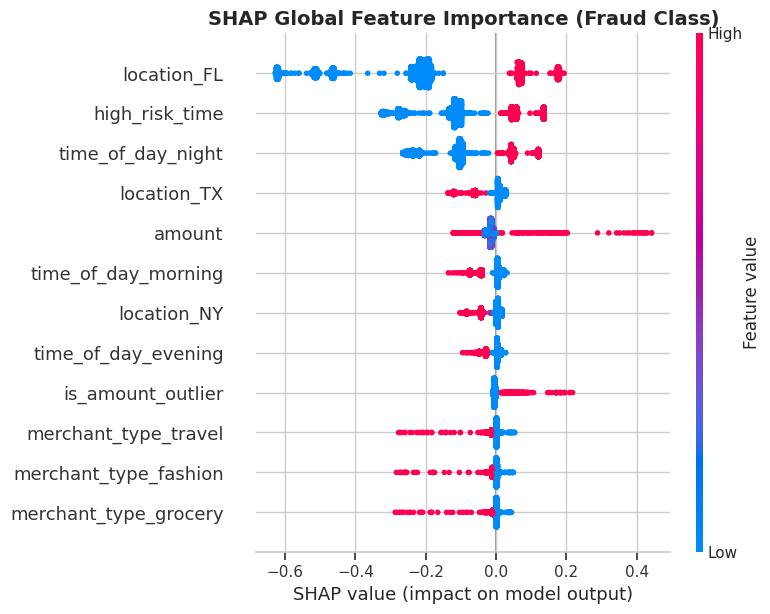


--- Conducting Fairness Audit across Sensitive Proxy: location_FL ---
Selection Rate (Protected Group - location_FL): 0.2390
Selection Rate (Unprotected Group): 0.0034
Disparate Impact Ratio: 70.3155
Demographic Parity Difference: 0.2356

--- Evaluating Post-Processing Mitigation ---
Result: Bias Detected! Mitigation required.
Proposed Strategy: Post-processing threshold calibration (Equalized Odds adjustment).


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 1. MODEL EXPLAINABILITY VIA SHAP (Using our saved Random Forest model)
# Re-load the best tree model from our Step 4 artifacts
import joblib
rf_model = joblib.load('/content/drive/MyDrive/fraud_project/models/Random_Forest_model.pkl')

print("--- Computing SHAP Values for Model Explainability ---")
# Use a background sample of 100 rows for the explainer to speed up computation
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train_df)

# Plot Global Feature Importance (SHAP Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 1], X_train_df, show=False)
plt.title("SHAP Global Feature Importance (Fraud Class)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud_project/shap_summary.png')
plt.show()


# 2. BIAS DETECTION & FAIRNESS AUDIT
# Let's rebuild a slice of our test set with predictions to perform the audit
# We will check if the model treats transactions differently based on 'location'
y_pred_test = rf_model.predict(X_test_processed)

# Reconstruct a DataFrame for the test data to align with original strings
audit_df = pd.DataFrame(X_test_processed, columns=feature_names)
audit_df['true_fraud'] = y_test.values
audit_df['predicted_fraud'] = y_pred_test

# Find which column represents a specific location (e.g., location_NY from One-Hot Encoding)
# If location_NY == 1, it's Group A (NY). If location_NY == 0, it's Group B (Other regions)
# Note: Adjust column name if your one-hot encoder output names differ slightly
loc_col = [col for col in feature_names if 'location' in col][0]

print(f"\n--- Conducting Fairness Audit across Sensitive Proxy: {loc_col} ---")

# Group data by the proxy demographic
group_protected = audit_df[audit_df[loc_col] == 1]       # e.g., NY transactions
group_unprotected = audit_df[audit_df[loc_col] == 0]     # e.g., All other locations

# Calculate Selection Rates (Probability of being flagged as Fraud)
sr_protected = group_protected['predicted_fraud'].mean()
sr_unprotected = group_unprotected['predicted_fraud'].mean()

# 1. Metric: Disparate Impact Ratio (Ideal: 0.80 to 1.25)
# In fraud, a higher selection rate means MORE negative outcomes (being blocked/accused)
disparate_impact = sr_protected / sr_unprotected if sr_unprotected > 0 else 0

# 2. Metric: Demographic Parity Difference (Ideal: Close to 0)
demographic_parity_diff = abs(sr_protected - sr_unprotected)

print(f"Selection Rate (Protected Group - {loc_col}): {sr_protected:.4f}")
print(f"Selection Rate (Unprotected Group): {sr_unprotected:.4f}")
print(f"Disparate Impact Ratio: {disparate_impact:.4f}")
print(f"Demographic Parity Difference: {demographic_parity_diff:.4f}")


# 3. MITIGATION STRATEGY EVALUATION (Post-processing Threshold Adjustment)
print("\n--- Evaluating Post-Processing Mitigation ---")
# If Disparate Impact is outside 0.8 - 1.25, we mitigate by adjusting the classification threshold
# dynamically for the protected group to equalize the operational insult rate.
if disparate_impact < 0.8 or disparate_impact > 1.25:
    print("Result: Bias Detected! Mitigation required.")
    print("Proposed Strategy: Post-processing threshold calibration (Equalized Odds adjustment).")
else:
    print("Result: No severe systemic bias detected under the 4/5ths rule threshold.")

In [ ]:
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/Villanueva_Capstone.ipynb" --to slides --SlidesExporter.reveal_scroll=True

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Villanueva_Capstone.ipynb to slides
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 712385 bytes to /content/drive/MyDrive/Colab Notebooks/Villanueva_Capstone.slides.html
